### Aprimoramente de imagens através de Operações Matemáticas
#### Operações como adição e multiplicação
#### Limiarização e mascaramento
#### Operações bit a bit como OR,AND,XOR

In [1]:
#importação das bibliotecas
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from zipfile import ZipFile
from urllib.request import urlretrieve

from IPython.display import Image

%matplotlib inline

In [2]:
#Baixando e descompactando os arquivos da aula
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")
    
    urlretrieve(url, save_path)
    
    try:
        with ZipFile(save_path) as z:
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

URL = r"https://www.dropbox.com/s/0oe92zziik5mwhf/opencv_bootcamp_assets_NB4.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), f"opencv_bootcamp_assets_NB4.zip")

if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)   

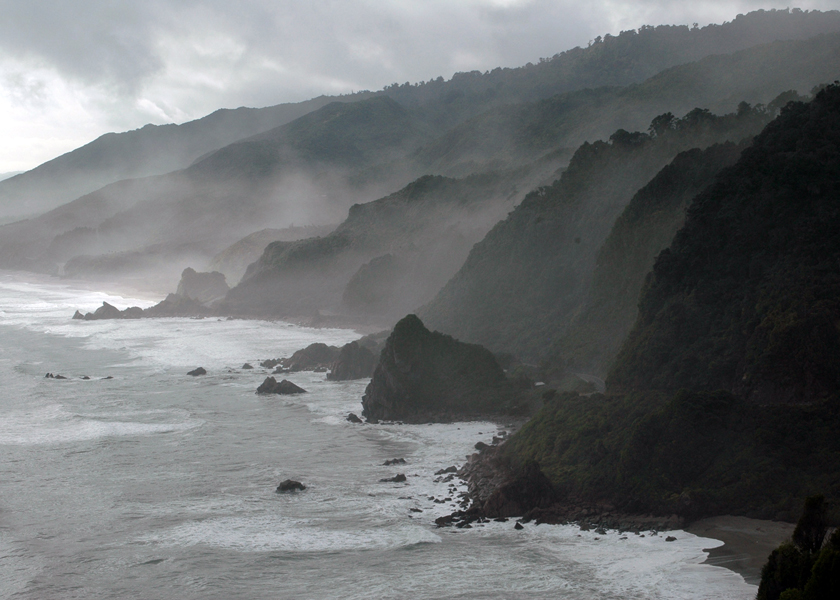

In [3]:
#carregando a imagem, passando para rgb e exibindo
img_bgr = cv2.imread("New_Zealand_Coast.jpg", cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

Image(filename="New_Zealand_Coast.jpg")

#### Para aumentar ou diminuir o brilho de uma imagem pode se utilizar operações de soma ou subtração

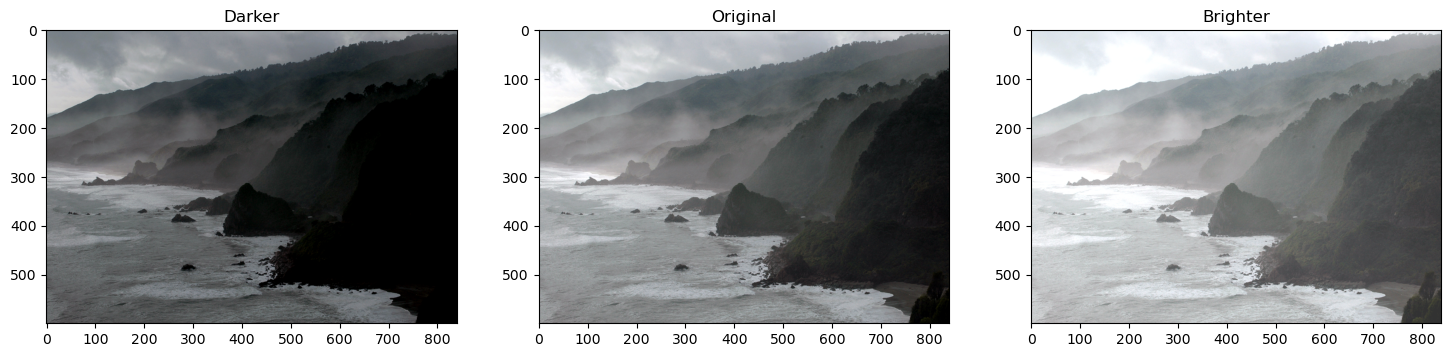

In [5]:
#Cria uma matriz com o tamanho da imagem e com o mesmo tipo de dados da imagem, inteira com 50
matrix = np.ones(img_rgb.shape, dtype="uint8") * 50

#Adiciona e subtrai das imagens a matriz de 50
img_rgb_brighter = cv2.add(img_rgb, matrix)
img_rgb_darker   = cv2.subtract(img_rgb, matrix)


#plota a imagem mais escura, a original e a com mais brilho
plt.figure(figsize=[18, 5])
plt.subplot(131); plt.imshow(img_rgb_darker);  plt.title("Darker");
plt.subplot(132); plt.imshow(img_rgb);         plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_brighter);plt.title("Brighter");

#### Para melhorar o contraste é possível utilizar multiplicações

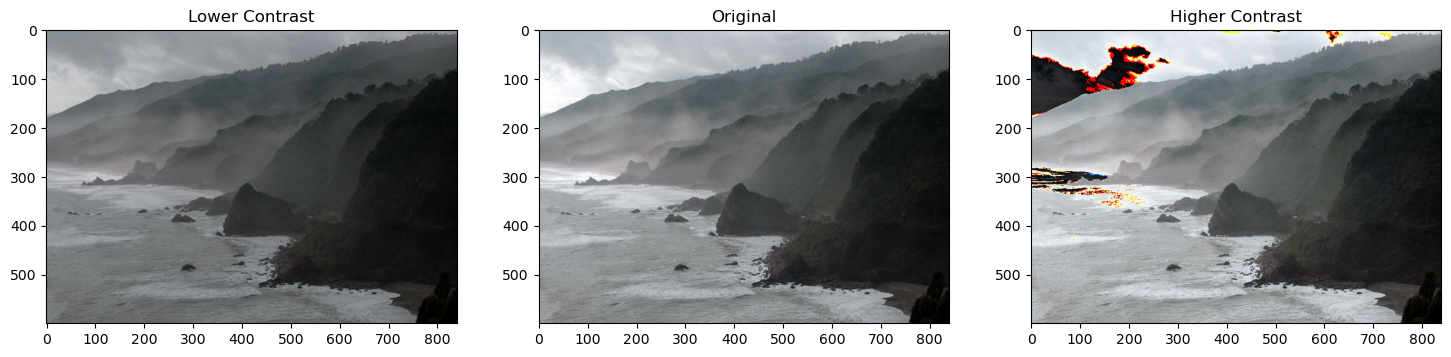

In [6]:
#Criando matrizes do tamanho da imagem com fatores de 0.8 e 1.2
matrix1 = np.ones(img_rgb.shape) * 0.8
matrix2 = np.ones(img_rgb.shape) * 1.2

#Fazendo a multiplicação das matrizes
img_rgb_darker   = np.uint8(cv2.multiply(np.float64(img_rgb), matrix1))
img_rgb_brighter = np.uint8(cv2.multiply(np.float64(img_rgb), matrix2))

#mostrando os resultados
plt.figure(figsize=[18,5])
plt.subplot(131); plt.imshow(img_rgb_darker);  plt.title("Lower Contrast");
plt.subplot(132); plt.imshow(img_rgb);         plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_brighter);plt.title("Higher Contrast");

#### A terceira imagem ficou daquele jeito porque ao multiplicar valores mais altos por 1.8, pode se ultrapassar o valor máximo de 255 

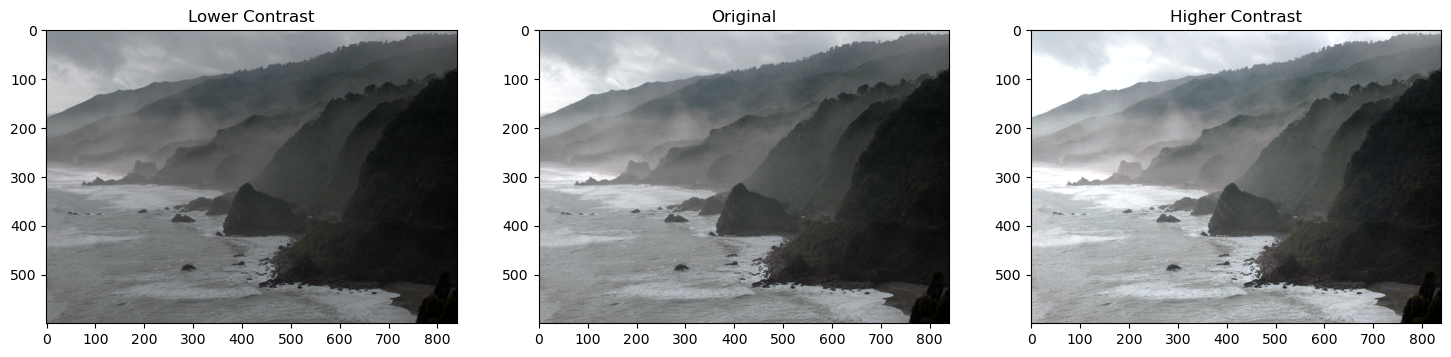

In [7]:
matrix1 = np.ones(img_rgb.shape) * 0.8
matrix2 = np.ones(img_rgb.shape) * 1.2

img_rgb_lower  = np.uint8(cv2.multiply(np.float64(img_rgb), matrix1))
img_rgb_higher = np.uint8(np.clip(cv2.multiply(np.float64(img_rgb), matrix2), 0, 255)) #Única diferença é esse np.clip que faz com que os números fiquem entre o range permitido de 0 a 255

plt.figure(figsize=[18,5])
plt.subplot(131); plt.imshow(img_rgb_lower); plt.title("Lower Contrast");
plt.subplot(132); plt.imshow(img_rgb);       plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_higher);plt.title("Higher Contrast");

(572, 800)


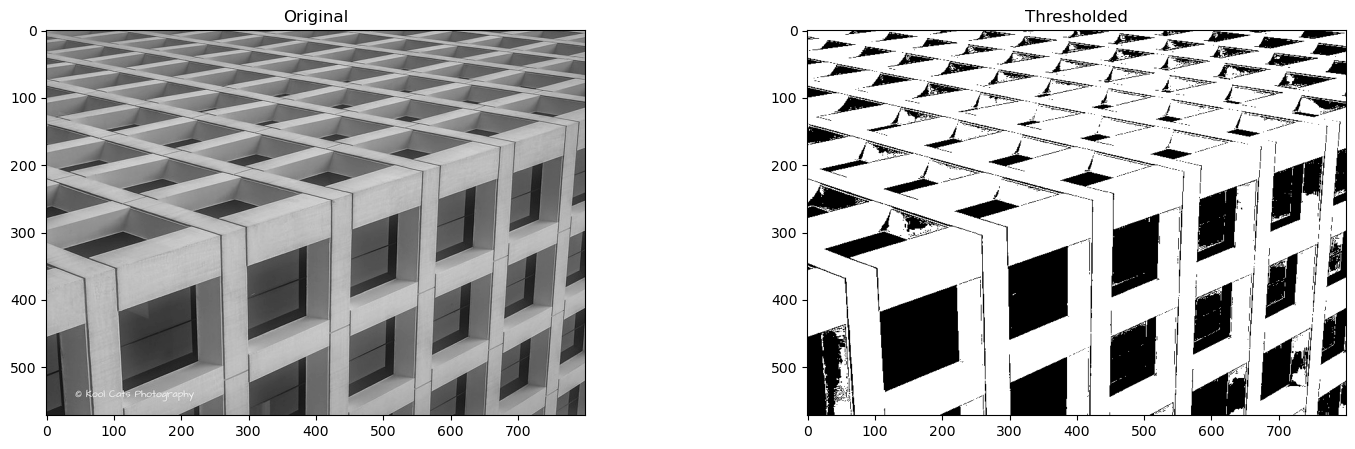

In [8]:
#Carrega a imagem e faz a limiarização para imagem binária para pixels acima de 100
img_read = cv2.imread("building-windows.jpg", cv2.IMREAD_GRAYSCALE)
retval, img_thresh = cv2.threshold(img_read, 100, 255, cv2.THRESH_BINARY)

#plotando as imagens
plt.figure(figsize=[18, 5])

plt.subplot(121);plt.imshow(img_read, cmap="gray");  plt.title("Original")
plt.subplot(122);plt.imshow(img_thresh, cmap="gray");plt.title("Thresholded")

print(img_thresh.shape)

#### A intenção aqui é carregar a imagem e fazer a extração do conteúdo importante através do mapa binário.
#### Feito 3 mapas, um com um limiar de 50 outro de 130 e outro com o limiar adaptativo

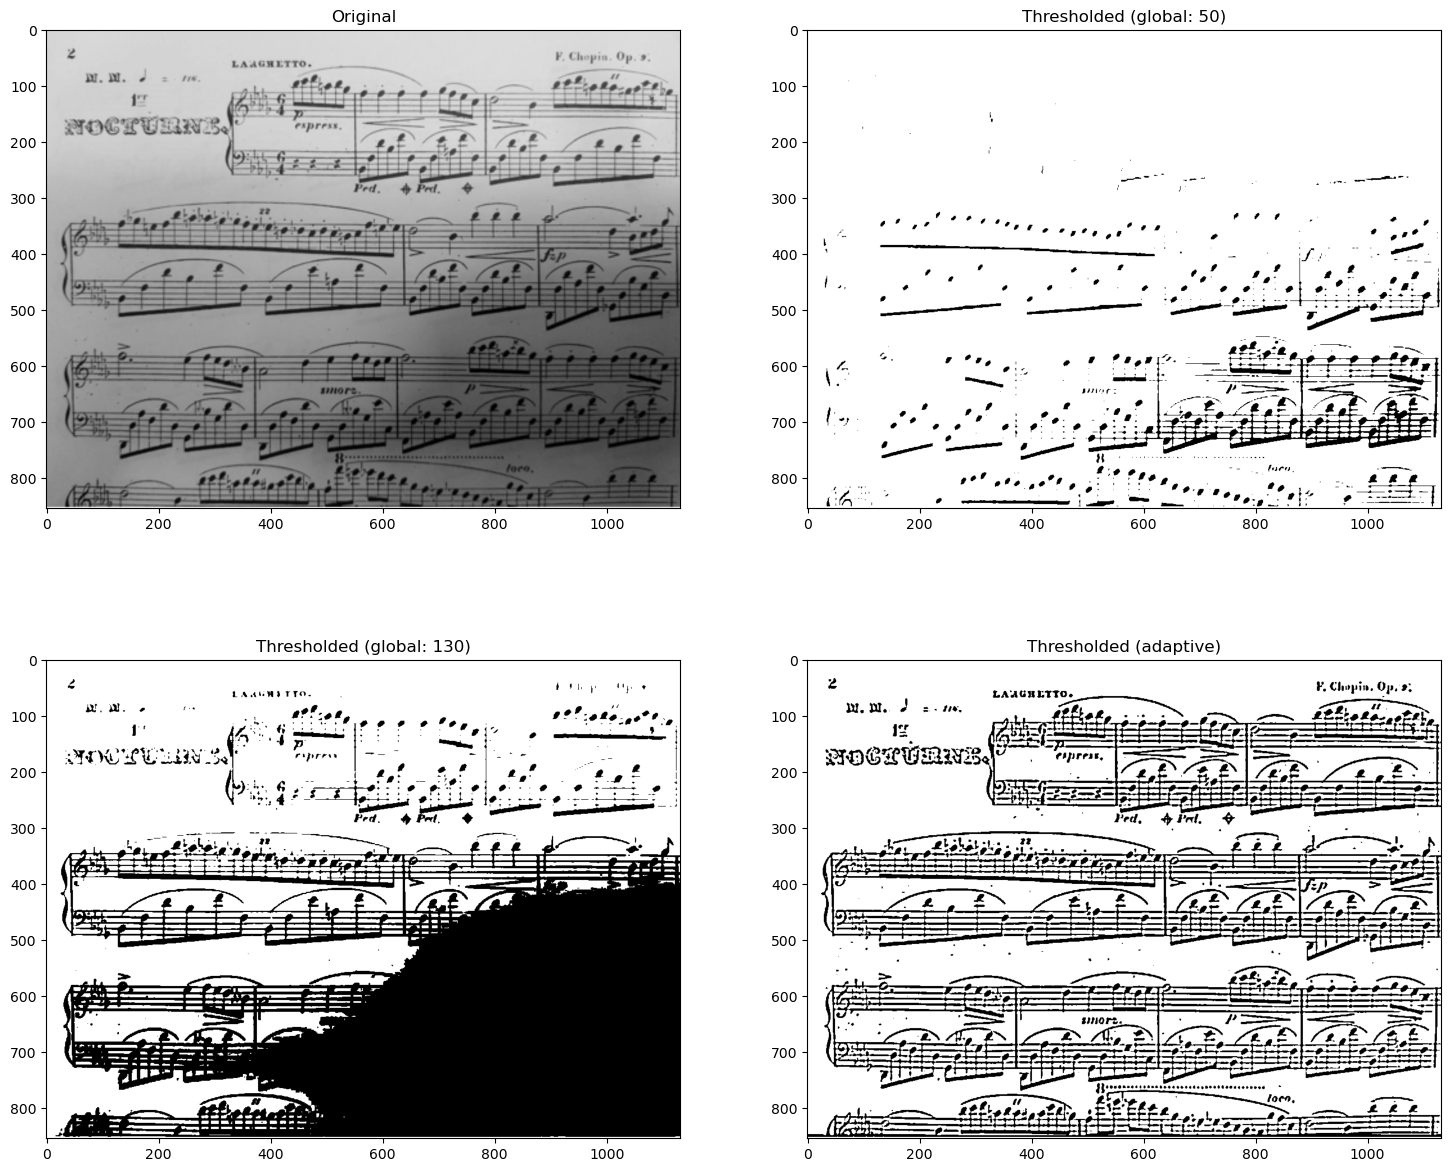

In [9]:
img_read = cv2.imread("Piano_Sheet_Music.png", cv2.IMREAD_GRAYSCALE)

retval, img_thresh_gbl_1 = cv2.threshold(img_read, 50, 255, cv2.THRESH_BINARY)
retval, img_thresh_gbl_2 = cv2.threshold(img_read, 130, 255, cv2.THRESH_BINARY)
img_thresh_adp = cv2.adaptiveThreshold(img_read, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 7)

plt.figure(figsize=[18,15])
plt.subplot(221); plt.imshow(img_read,        cmap="gray");  plt.title("Original");
plt.subplot(222); plt.imshow(img_thresh_gbl_1,cmap="gray");  plt.title("Thresholded (global: 50)");
plt.subplot(223); plt.imshow(img_thresh_gbl_2,cmap="gray");  plt.title("Thresholded (global: 130)");
plt.subplot(224); plt.imshow(img_thresh_adp,  cmap="gray");  plt.title("Thresholded (adaptive)");

(200, 499)


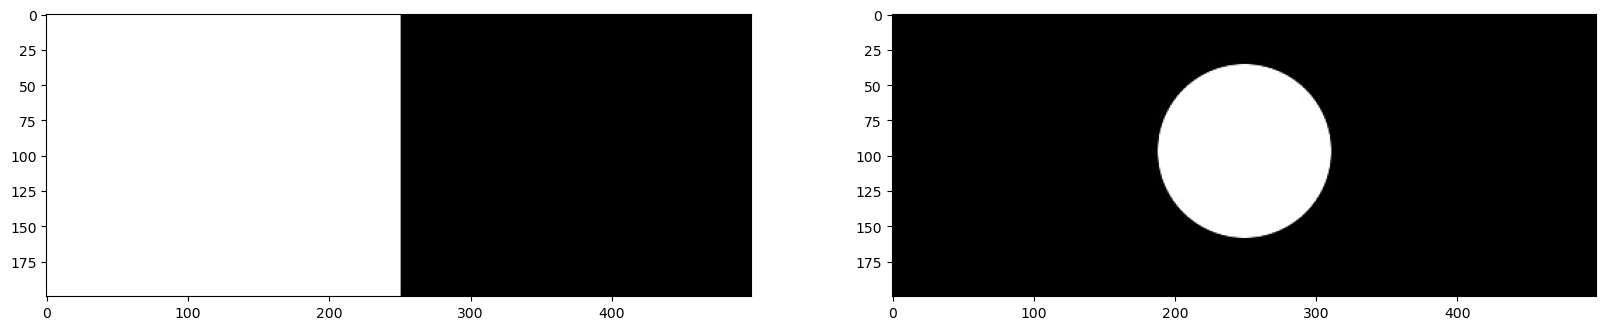

In [11]:
#Carregando as imagens e plotando para usar de exemplo nos exercicios de bit a bit
img_rec = cv2.imread("rectangle.jpg", cv2.IMREAD_GRAYSCALE)

img_cir = cv2.imread("circle.jpg", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=[20, 5])
plt.subplot(121);plt.imshow(img_rec, cmap="gray")
plt.subplot(122);plt.imshow(img_cir, cmap="gray")
print(img_rec.shape)

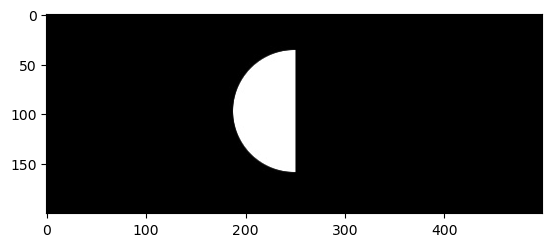

In [14]:
#Operação AND bit a bit onde vai retornar branco onde em ambas as imagens é branco 
result = cv2.bitwise_and(img_rec, img_cir, mask=None)
plt.imshow(result, cmap="gray")

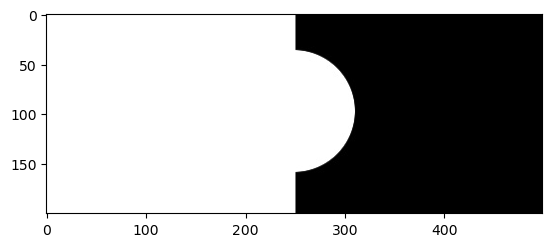

In [15]:
#Operação OR bit a bit onde vai retornar branco onde em alguma das imagens for branco
result = cv2.bitwise_or(img_rec, img_cir, mask=None)
plt.imshow(result, cmap="gray")

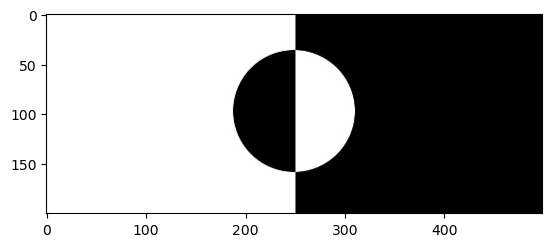

In [16]:
#Operação XOR onde vai retornar branco somente se nas duas imagens o pixel correspondente não for igual
result = cv2.bitwise_xor(img_rec, img_cir, mask=None)
plt.imshow(result, cmap="gray")

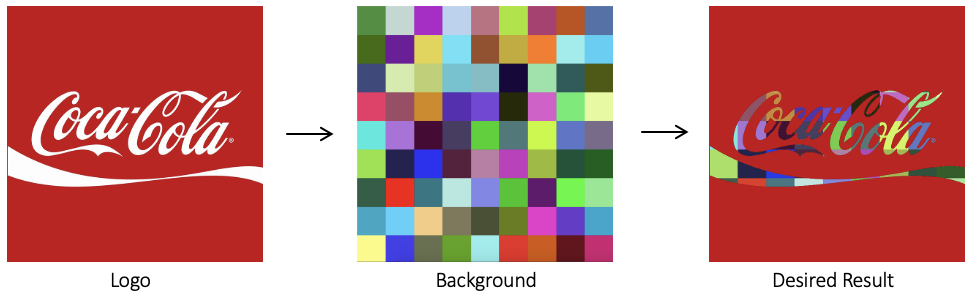

In [17]:
#Carregando a imagem do resultado
Image(filename='Logo_Manipulation.png')

(700, 700, 3)


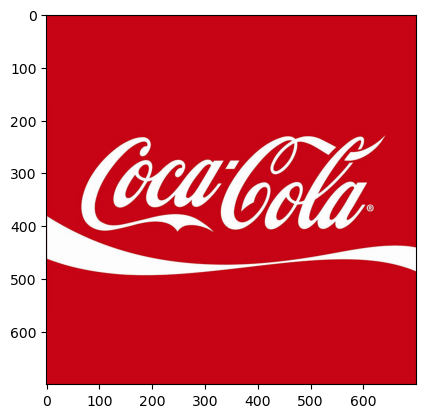

In [18]:
#Carregando a iamgem, passando para rgb, plotando e pegando a altura/largura
img_bgr = cv2.imread("coca-cola-logo.png")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

print(img_rgb.shape)

logo_w = img_rgb.shape[0]
logo_h = img_rgb.shape[1]

(700, 700, 3)


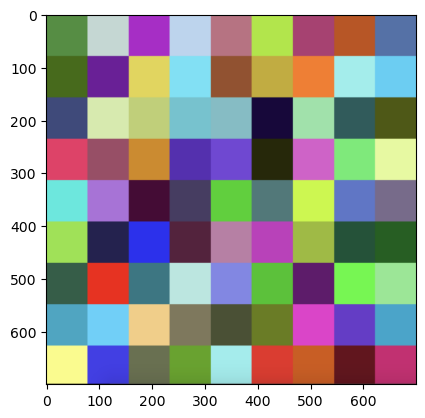

In [19]:
#carrega a imagem e transforma para rgb
img_background_bgr = cv2.imread("checkerboard_color.png")
img_background_rgb = cv2.cvtColor(img_background_bgr, cv2.COLOR_BGR2RGB)

#Calcula para fazer um redimensionamento proporcional
aspect_ratio = logo_w / img_background_rgb.shape[1]
dim = (logo_w, int(img_background_rgb.shape[0] * aspect_ratio))

#Faz com que ambas imagens tenha o mesmo tamanho
img_background_rgb = cv2.resize(img_background_rgb, dim, interpolation=cv2.INTER_AREA)

#plota a imagem
plt.imshow(img_background_rgb)
print(img_background_rgb.shape)

(700, 700)


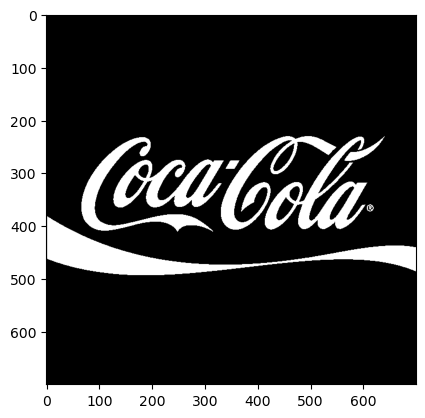

In [34]:
#passando a logo para escala de cinza
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

#criando uma máscara binária 
retval, img_mask = cv2.threshold(img_gray, 128, 255, cv2.THRESH_BINARY)

plt.imshow(img_mask, cmap="gray")
print(img_mask.shape)

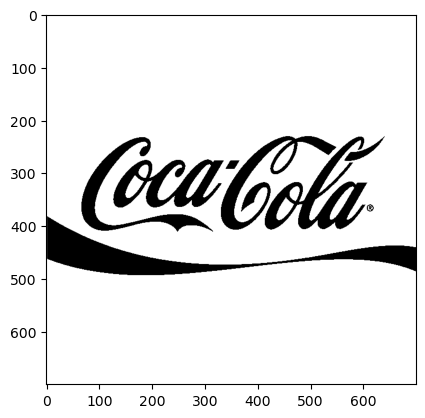

In [21]:
#Invertendo a máscara binária criada
img_mask_inv = cv2.bitwise_not(img_mask)
plt.imshow(img_mask_inv, cmap="gray")

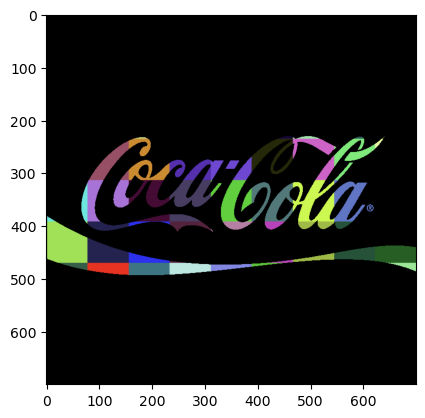

In [27]:
#Criando um fundo colorido para a logo através da operação AND
img_background = cv2.bitwise_and(img_background_rgb, img_background_rgb, mask=img_mask)
plt.imshow(img_background)

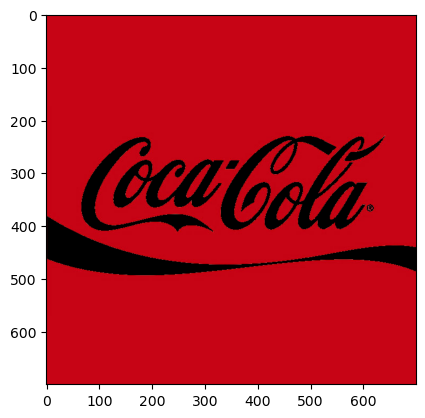

In [28]:
#Isolando as letras da logo para preto
img_foreground = cv2.bitwise_and(img_rgb, img_rgb, mask=img_mask_inv)
plt.imshow(img_foreground)

True

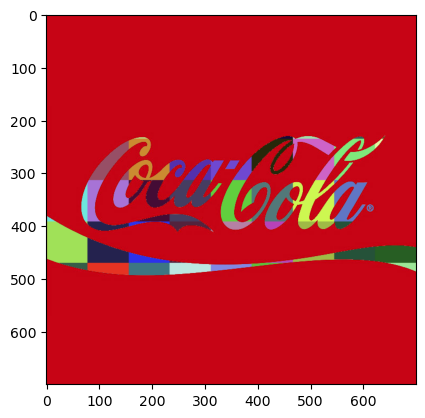

In [29]:
#Adicionando o fundo criado para a imagem com as letras em preto
result = cv2.add(img_background, img_foreground)
plt.imshow(result)
cv2.imwrite("logo_final.png", result[:, :, ::-1])